# **Discussões**

# Análise de Sentimentos — Modelos Léxicos

Utilizamos apenas modelos léxicos (Vader, leIA e TextBlob). Comparando os resultados dos três, concluímos que o uso do **leIA** (adaptação do VADER para o português) é mais preciso em comparação aos demais modelos, levando em consideração que a maioria das avaliações está em português.

---

### <span style="color:#EF9F27">Vader — Léxico</span>

Utilizando o Vader, tivemos uma discrepância na distribuição dos dados, com maior destaque para os valores <span style="color:#EF9F27">**neutros**</span>, provavelmente por conta de sua base ser em inglês, tornando imprecisos e pouco realistas os valores de sentimento negativo e positivo na base de dados. Além disso, o modelo praticamente ignora a categoria <span style="color:#E24B4A">**"muito negativo"**</span> e apresenta poucos registros classificados como <span style="color:#1D9E75">**"muito positivo"**</span>.

---

### <span style="color:#1D9E75">leIA — Léxico</span>

Com o leIA, tivemos maior precisão nos resultados, pois a maioria das classificações foi condizente com os dados e valores reais. O modelo reconhece com mais facilidade <span style="color:#1D9E75">**palavras em português, gírias e pontuações**</span>, tornando mais precisas as classificações em categorias específicas, como <span style="color:#E24B4A">**"muito negativo"**</span> e <span style="color:#1D9E75">**"muito positivo"**</span>.

---

### <span style="color:#E24B4A">TextBlob — Léxico</span>

Já utilizando o TextBlob, percebemos maiores limitações. O modelo é praticamente <span style="color:#E24B4A">**exclusivo para o inglês**</span>, e mesmo no idioma apresenta dificuldades para interpretar <span style="color:#E24B4A">**gírias e ironias**</span>. Entre os três modelos analisados, é o que apresenta as <span style="color:#E24B4A">**maiores limitações**</span> para a base de dados utilizada.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [19]:
resultados = pd.read_parquet("../data/processed/resultados.parquet")

In [35]:
avaliacoes = pd.read_parquet("../data/processed/avaliacoes.parquet")

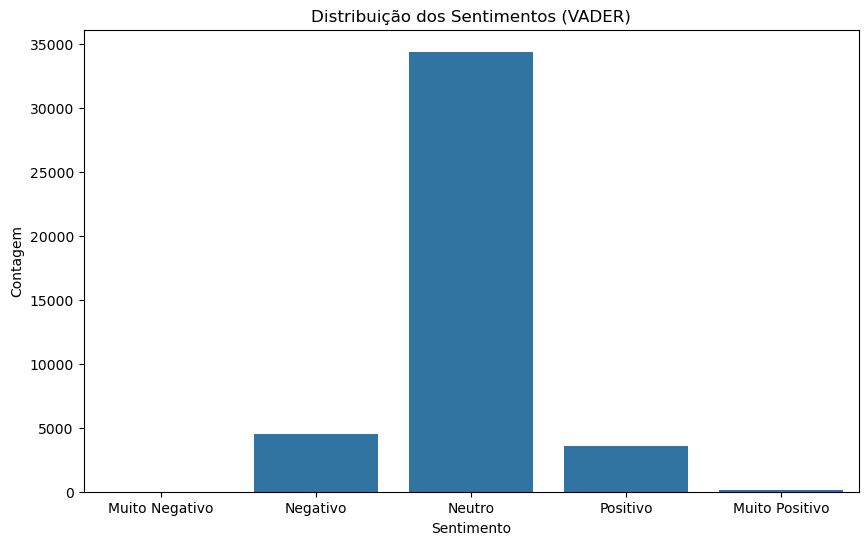

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x='vader_label', data=resultados, order=['Muito Negativo', 'Negativo', 'Neutro', 'Positivo', 'Muito Positivo'])
plt.title('Distribuição dos Sentimentos (VADER)')
plt.xlabel('Sentimento')
plt.ylabel('Contagem')
plt.show()

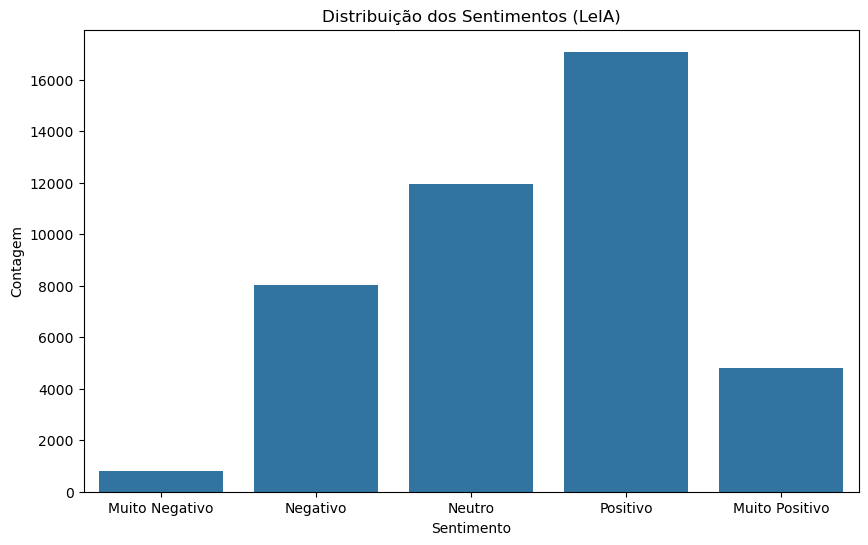

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(x='leia_label', data=resultados, order=['Muito Negativo', 'Negativo', 'Neutro', 'Positivo', 'Muito Positivo'])
plt.title('Distribuição dos Sentimentos (LeIA)')
plt.xlabel('Sentimento')
plt.ylabel('Contagem')
plt.show()

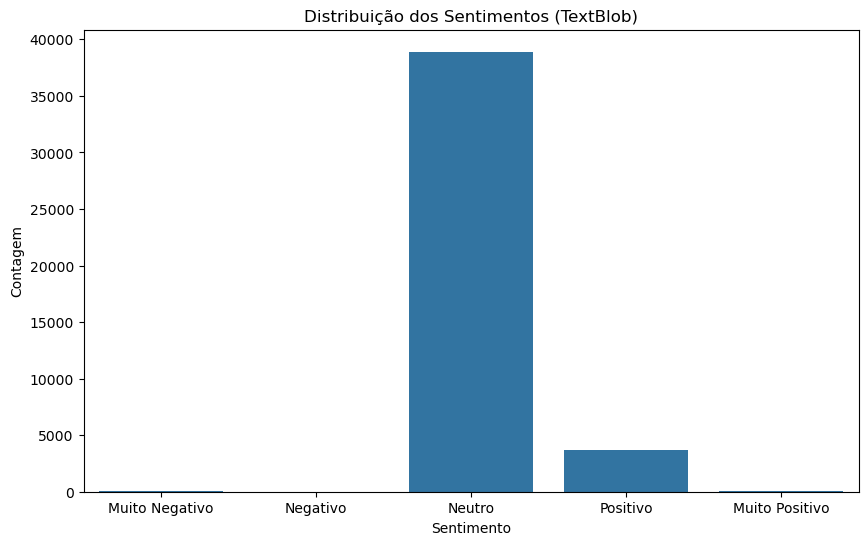

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(x='textblob_label', data=resultados, order=['Muito Negativo', 'Negativo', 'Neutro', 'Positivo', 'Muito Positivo'])
plt.title('Distribuição dos Sentimentos (TextBlob)')
plt.xlabel('Sentimento')
plt.ylabel('Contagem')
plt.show()

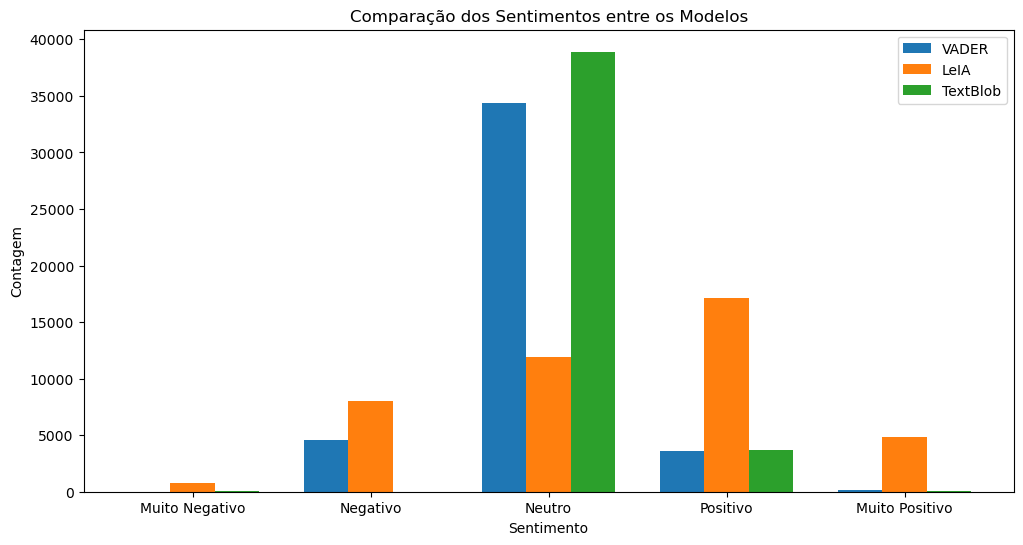

In [30]:
### Comparação entre os modelos
labels = ['Muito Negativo', 'Negativo', 'Neutro', 'Positivo', 'Muito Positivo']
contagem_vader = resultados['vader_label'].value_counts().reindex(labels, fill_value=0)
contagem_leia = resultados['leia_label'].value_counts().reindex(labels, fill_value=0)
contagem_textblob = resultados['textblob_label'].value_counts().reindex(labels, fill_value    =0)
plt.figure(figsize=(12, 6))
x = np.arange(len(labels))
width = 0.25
plt.bar(x - width, contagem_vader, width=width, label='VADER')
plt.bar(x, contagem_leia, width=width, label='LeIA')
plt.bar(x + width, contagem_textblob, width=width, label='TextBlob')
plt.xticks(x, labels)
plt.title('Comparação dos Sentimentos entre os Modelos')
plt.xlabel('Sentimento')
plt.ylabel('Contagem')
plt.legend()

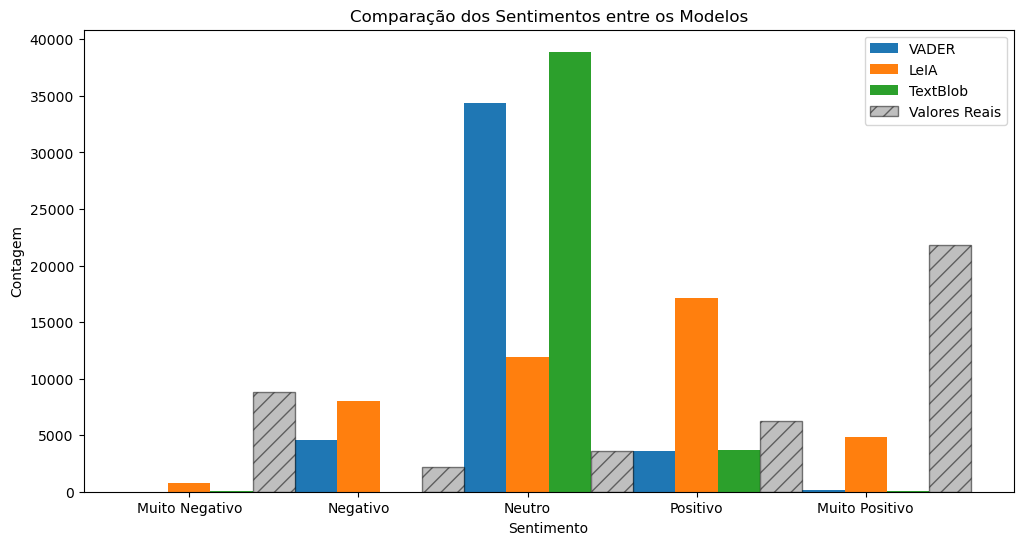

In [40]:
### Comparação entre os modelos e os valores reais
labels = ['Muito Negativo', 'Negativo', 'Neutro', 'Positivo', 'Muito Positivo']
contagem_vader = resultados['vader_label'].value_counts().reindex(labels, fill_value=0)
contagem_leia = resultados['leia_label'].value_counts().reindex(labels, fill_value=0)
contagem_textblob = resultados['textblob_label'].value_counts().reindex(labels, fill_value=0)
valores_reais = avaliacoes['review_label'].value_counts().reindex(labels, fill_value=0)
plt.figure(figsize=(12, 6))
x = np.arange(len(labels))
width = 0.25
plt.bar(x - width, contagem_vader, width=width, label='VADER')
plt.bar(x, contagem_leia, width=width, label='LeIA')
plt.bar(x + width, contagem_textblob, width=width, label='TextBlob')
plt.bar(x + 2*width, valores_reais, width=width, label='Valores Reais', color='gray', alpha=0.5, edgecolor='black', hatch='//')
plt.xticks(x, labels)
plt.title('Comparação dos Sentimentos entre os Modelos')
plt.xlabel('Sentimento')
plt.ylabel('Contagem')
plt.legend()

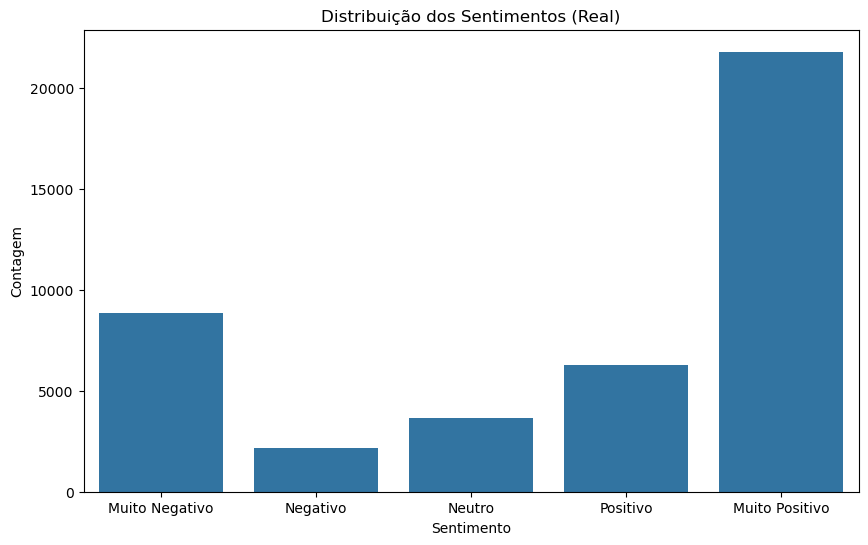

In [36]:
#distribuição dos sentimentos (real)
plt.figure(figsize=(10, 6))
sns.countplot(x='review_label', data=avaliacoes, order=['Muito Negativo', 'Negativo', 'Neutro', 'Positivo', 'Muito Positivo'])
plt.title('Distribuição dos Sentimentos (Real)')
plt.xlabel('Sentimento')
plt.ylabel('Contagem')
plt.show()

### Comparação entre os três modelos

Ao compararmos os resultados obtidos pelos modelos Vader, leIA e TextBlob, observamos que o <span style="color:#1D9E75">**leIA**</span> apresentou o melhor desempenho para a análise de sentimentos da base utilizada — adaptado ao português, o modelo conseguiu interpretar com maior precisão palavras, expressões, gírias e sinais de pontuação presentes nas avaliações.

O <span style="color:#EF9F27">**Vader**</span> apresentou resultados razoáveis, porém com uma concentração excessiva de classificações neutras, o que pode ser explicado pelo fato de ter sido desenvolvido originalmente para o idioma inglês. Já o <span style="color:#E24B4A">**TextBlob**</span> demonstrou as maiores limitações, apresentando dificuldades na interpretação de textos em português e na identificação de nuances linguísticas, como gírias e ironias.

Concluímos que o <span style="color:#1D9E75">**leIA**</span> foi o modelo mais adequado para este projeto, produzindo resultados mais coerentes e próximos da realidade da base de dados analisada.

In [27]:
#distribuição dos valores reais


ValueError: Could not interpret value `sentimento` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>